# B-field orientation (Line Integral Convolution)

Produces column density map as the background colormap with the projected B-field orientation encoded as LIC texture. Three orthogonal views in a single figure: face-on XY (large), XZ edge-on (bottom strip), YZ edge-on (right strip). Panel sizes are proportional to physical extents so the coordinate axes align across panels, same as the original reference layout.

Under the hood it's Stokes Q/U per particle, histogrammed onto a 2D grid, then two-pass LIC blended into the HSV channels. Cut the data to the region you care about before projecting — that's what makes a fine grid fast enough to actually see the striations.

Needs an MHD snapshot. The l-b sky view is at the end if you also want the "observer perspective" version.

In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path("..").resolve()))

from simviz.utils import read_snapshot_hdf5, calc_bfield_uG
from simviz.projections import rotate_to_bar_frame
from simviz.field_plots import plot_threepanel_bfield, plot_planck_style_bfield, project_bfield_lb  # noqa: F401

EXAMPLE_OUT = Path("../example_output")
EXAMPLE_OUT.mkdir(exist_ok=True)

print("imports done")

imports done


## Load snapshot

In [5]:
# Set this path to an MHD snapshot (must contain PartType0['MagneticField'])
snap_path = Path("../sample_snaps/phoenix_stinks_1Msun_999.hdf5")

data, header = read_snapshot_hdf5(snap_path)
print(f"Using snapshot: {snap_path}")
print("PartType0 fields:", sorted(data.keys()))
print(f"N_particles = {len(data['Coordinates']):,}")

try:
    bfield_code = np.asarray(data["MagneticField"])
except KeyError as exc:
    raise RuntimeError("Snapshot is missing PartType0['MagneticField'].") from exc


t   = float(header["Time"])
box = float(header["BoxSize"])

x, y, z = np.array(data["Coordinates"]).T
Bx, By, Bz = calc_bfield_uG(bfield_code).T
density = np.array(data["Density"])

x -= box / 2;  y -= box / 2;  z -= box / 2
x, y, Bx, By = rotate_to_bar_frame(x, y, Bx, By, t)

print(f"Loaded {len(x):,} particles, t = {t:.2f} code units")

Using snapshot: ../sample_snaps/phoenix_stinks_1Msun_999.hdf5
PartType0 fields: ['ChemicalAbundances', 'Coordinates', 'Density', 'DustTemperature', 'InternalEnergy', 'MagneticField', 'MagneticFieldDivergence', 'MagneticFieldDivergenceAlternative', 'Masses', 'ParticleIDs', 'PotentialPeak', 'Velocities']
N_particles = 88,964,811
Loaded 88,964,811 particles, t = 2.45 code units


## Three-panel figure

`xlim`, `ylim`, `zlim` define the exact 3D slab that gets projected — the XY map only integrates gas inside `zlim`, the XZ map only integrates gas inside `ylim`, and so on. Same idea as the reference voxel grid.

`dpix` is the pixel size (code units = 100 pc). At `dpix=0.05` over ±500 pc you get ~200 pixels per axis — fine enough to see the striations and fast enough for interactive use (~5–10 s for LIC). For publication quality drop it to 0.02 or smaller; for quick iteration go up to 0.1. The pure-Python LIC scales as N_pixels × kernel_length so it gets slow fast at high resolution.

`norm_lim=(a, b)` sets the column density log scale from 10^a to 10^b — same as the reference `logspace(-0.5, 4.5)`. Adjust if the colormap looks washed out or oversaturated.

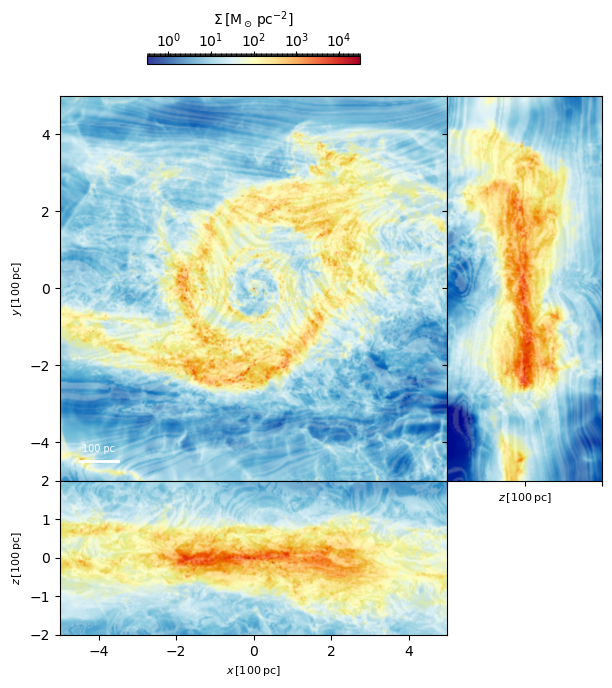

In [6]:
# Shared plotting knobs — same symbols used in zoom (fig2) and l-b Planck (fig3)
PLOT_SEED = 26
PROJECTION_METHOD = "nearest_nd"  # or "histogram"
LIC_KERNELS = (41, 81)  # striation scale; larger tuple → smoother texture
IMSHOW_INTERP = "bicubic"  # Σ maps + Planck background; use "nearest" for blocky pixels
THREE_PANEL_SMOOTH_SIGMA_PX = 0.2  # Gaussian smoothing on projected Σ before LIC
LB_SMOOTH_SIGMA_PX = 0.0  # optional smoothing on l-b |B⊥| map (same grid units as dl/db)

# l-b panel: log10(|B⊥| / µG) range for Planck-style plot; None → auto percentiles
NORM_LIM_LB = (-1.0, 3.0)

# l-b sky histogram grid (degrees): smaller dl, db → more pixels, finer LIC (slower)
LB_LMIN, LB_LMAX = -2.3, 2.3
LB_BMIN, LB_BMAX = -0.85, 0.85
LB_DL = 0.0125  # default was 0.025 (~184×68 bins); halve again for publication runs
LB_DB = 0.0125
LB_FIGSIZE_INCHES = (10.0, 10.0)  # matplotlib figure size; raise dpi when saving for sharper PNG

# plotting parameters to tweak (reference-style defaults)
xlim = (-5.0, 5.0)    # ±500 pc — matches DX=DY=0.5 kpc
ylim = (-5.0, 5.0)
zlim = (-2.0, 2.0)    # ±200 pc z-slab — matches DZ=0.2 kpc
dpix = 0.03           # 3 pc/pixel

# Explicit controls (easy to tune)
norm_lim = (-0.5, 4.5)   # update from percentile helper cell below if needed
scalebar_length = 1.0     # code units (1.0 = 100 pc)
scalebar_label = "100 pc"
density[density<10**norm_lim[0]]=norm_lim[0]

fig, axes = plot_threepanel_bfield(
    x, y, z, Bx, By, Bz, density,
    xlim=xlim,
    ylim=ylim,
    zlim=zlim,
    dpix=dpix,
    norm_lim=norm_lim,
    cmap="RdYlBu_r",
    seed=PLOT_SEED,
    lic_kernels=LIC_KERNELS,
    projection_method=PROJECTION_METHOD,
    smooth_sigma_px=THREE_PANEL_SMOOTH_SIGMA_PX,
    interpolation=IMSHOW_INTERP,
    colorbar_label=r"$\Sigma\,[\mathrm{M_\odot\,pc^{-2}}]$",
    scalebar_length=scalebar_length,
    scalebar_label=scalebar_label,
)

fig.savefig(EXAMPLE_OUT / "bfield_threepanel_main.png", dpi=180, bbox_inches="tight")
plt.show()

Percentile helper for `norm_lim` (next cell): run it before plotting to get data-driven log-scale suggestions for `Σ`.

In [7]:
# Percentile helper for norm_lim
# helps find log10(\Sigma [Msun/pc^2]) range for successful plotting :)

box_sel = (
    (x >= xlim[0]) & (x <= xlim[1]) &
    (y >= ylim[0]) & (y <= ylim[1]) &
    (z >= zlim[0]) & (z <= zlim[1])
)

xv = x[box_sel]
yv = y[box_sel]
rhov = density[box_sel]

# Match the XY projection scaling used in plot_threepanel_bfield:
# sigma_xy_code = sum(rho) per pixel, then convert to Msun/pc^2 via * dpix_z / 1e4.
xe = np.arange(xlim[0] - dpix / 2.0, xlim[1] + 1.5 * dpix, dpix)
ye = np.arange(ylim[0] - dpix / 2.0, ylim[1] + 1.5 * dpix, dpix)
H, _, _ = np.histogram2d(xv, yv, bins=(xe, ye), weights=rhov)
sigma_xy = H.T * dpix / 1.0e4  # dpix_z defaults to dpix

pos = sigma_xy[sigma_xy > 0]
if pos.size == 0:
    print("No positive Σ bins in selected region.")
else:
    pct_pairs = [(1, 99), (2, 99.5), (5, 99.5), (10, 99.9)]
    print("Suggested norm_lim = (log10(p_lo), log10(p_hi))")
    for plo, phi in pct_pairs:
        lo, hi = np.percentile(pos, [plo, phi])
        print(f"  p{plo:>4.1f}-p{phi:<5.1f}: ({np.log10(lo):.2f}, {np.log10(hi):.2f})")

    # Convenient default recommendation
    lo, hi = np.percentile(pos, [2, 99.5])
    print(f"\nRecommended starter: norm_lim = ({np.log10(lo):.2f}, {np.log10(hi):.2f})")

Suggested norm_lim = (log10(p_lo), log10(p_hi))
  p 1.0-p99.0 : (-1.03, 6.17)
  p 2.0-p99.5 : (-0.79, 6.67)
  p 5.0-p99.5 : (-0.39, 6.67)
  p10.0-p99.9 : (0.02, 7.53)

Recommended starter: norm_lim = (-0.79, 6.67)


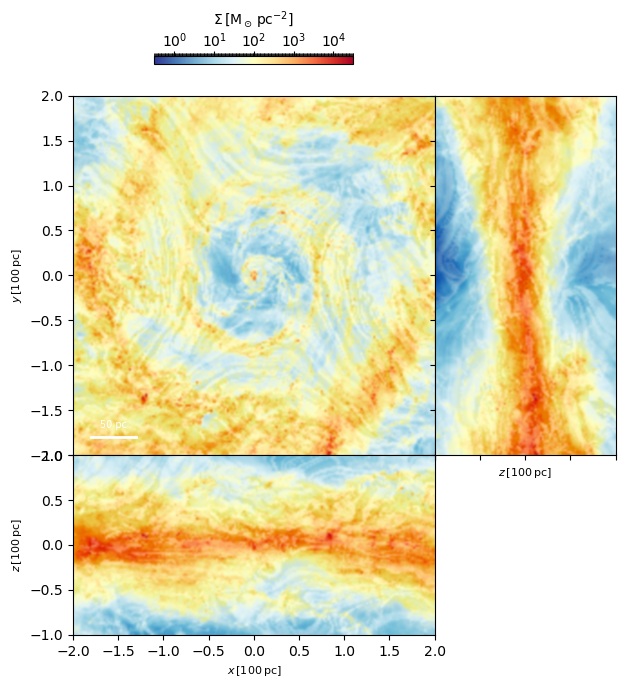

In [8]:
fig2, axes2 = plot_threepanel_bfield(
    x, y, z, Bx, By, Bz, density,
    xlim=(-2.0, 2.0),
    ylim=(-2.0, 2.0),
    zlim=(-1.0, 1.0),
    dpix=0.02,           # 2 pc/pixel → 200×200 for ±200 pc
    norm_lim=(-0.5, 4.5),
    cmap="RdYlBu_r",
    seed=PLOT_SEED,
    projection_method=PROJECTION_METHOD,
    lic_kernels=LIC_KERNELS,
    smooth_sigma_px=THREE_PANEL_SMOOTH_SIGMA_PX,
    interpolation=IMSHOW_INTERP,
    colorbar_label=r"$\Sigma\,[\mathrm{M_\odot\,pc^{-2}}]$",
    scalebar_length=0.5,
    scalebar_label="50 pc",
)
fig2.savefig(EXAMPLE_OUT / "bfield_threepanel_zoom.png", dpi=180, bbox_inches="tight")
plt.show()

## l-b view from the Sun

Same Stokes-parameter approach, but projected along lines of sight from the Sun — x-axis is Galactic longitude, y-axis is latitude. This is what you'd compare against Planck polarization maps of the CMZ. Background is the density-weighted mean plane-of-sky |B|.

In [9]:
lb_grid = {
    "lmin": LB_LMIN,
    "lmax": LB_LMAX,
    "dl": LB_DL,
    "bmin": LB_BMIN,
    "bmax": LB_BMAX,
    "db": LB_DB,
}

# project_bfield_lb hists particles into l/b cells: N_l ≈ (lmax-lmin)/dl, N_b ≈ (bmax-bmin)/db
# project_bfield_lb handles all particles — it bins by l/b so only the CMZ
# window contributes; the wider galaxy is projected but not shown
ux_lb, uy_lb, B_perp_lb, sigma_lb, ls, bs = project_bfield_lb(
    x, y, z, Bx, By, Bz, density, grid=lb_grid
)

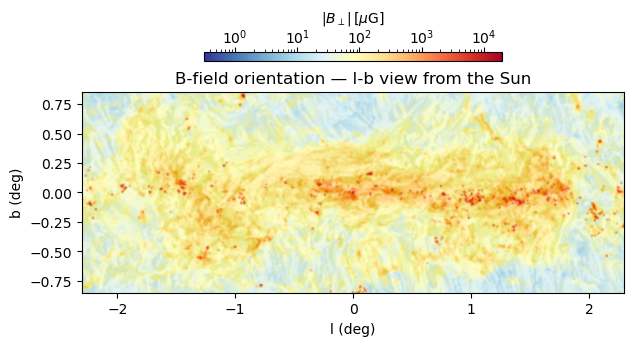

In [15]:
fig3, ax3, _ = plot_planck_style_bfield(
    B_perp_lb,
    ux_lb,
    uy_lb,
    ls,
    bs,
    norm_lim=(-0.5, 4.3),
    cmap="RdYlBu_r",
    #figsize=LB_FIGSIZE_INCHES,
    seed=PLOT_SEED,
    lic_kernels=LIC_KERNELS,
    interpolation=IMSHOW_INTERP,
    smooth_sigma_px=LB_SMOOTH_SIGMA_PX,
    #norm_lim=NORM_LIM_LB,
    colorbar_label=r"$|B_\perp|\,[\mu\mathrm{G}]$",
)
ax3.set_xlabel("l (deg)")
ax3.set_ylabel("b (deg)")
ax3.set_title("B-field orientation — l-b view from the Sun")
fig3.savefig(EXAMPLE_OUT / "bfield_lb_planck.png", dpi=180, bbox_inches="tight")
plt.show()

In [ ]:
# end of notebook